## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
# Load dataset
df = pd.read_csv('stock_prices_daily.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (184138, 11)


,Date,Ticker,Company_Name,Sector,Industry,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-03 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,71.629153,72.455966,71.472469,71.696648,71.696648,146322800
1,2020-01-06 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,70.819208,72.306506,70.568510,72.267937,72.267937,118387200
2,2020-01-07 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,72.277571,72.533087,71.708687,71.928047,71.928047,108872000
3,2020-01-08 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,71.631559,73.386431,71.631559,73.085114,73.085114,132079200
4,2020-01-09 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,74.061360,74.830322,73.810669,74.637482,74.637482,170108400


## 2. Data Cleaning

In [4]:
# Check data types and missing values
print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Data types:
Date             object
Ticker           object
Company_Name     object
Sector           object
Industry         object
Open            float64
High            float64
Low             float64
Close           float64
Adj_Close       float64
Volume            int64
dtype: object

Missing values:
Date            0
Ticker          0
Company_Name    0
Sector          0
Industry        0
Open            0
High            0
Low             0
Close           0
Adj_Close       0
Volume          0
dtype: int64


In [5]:
# Clean date column — strip timezone info
df['Date'] = pd.to_datetime(df['Date'].str[:10])

# Check for duplicates
dupes = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f'Duplicate rows (Date + Ticker): {dupes}')

# Drop duplicates if any
df = df.drop_duplicates(subset=['Date', 'Ticker'])

# Sort by Ticker and Date
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'\nCleaned dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print(f'Unique tickers: {df["Ticker"].nunique()}')
print(f'Unique sectors: {df["Sector"].nunique()}')
print(f'Sectors: {df["Sector"].unique().tolist()}')

Duplicate rows (Date + Ticker): 0

Cleaned dataset shape: (184138, 11)
Date range: 2020-01-03 00:00:00 to 2026-02-11 00:00:00
Unique tickers: 120
Unique sectors: 9
Sectors: ['Technology', 'Healthcare', 'Financial Services', 'Consumer Cyclical', 'Basic Materials', 'Industrials', 'Consumer Defensive', 'Communication Services', 'Energy']


## 3. Exploratory Data Analysis

In [6]:
# Dataset overview
print('=== Dataset Summary ===')
print(f'Total records:   {len(df):,}')
print(f'Unique tickers:  {df["Ticker"].nunique()}')
print(f'Unique sectors:  {df["Sector"].nunique()}')
print(f'Date range:      {df["Date"].min().date()} to {df["Date"].max().date()}')
print()
print('Tickers per sector:')
print(df.groupby('Sector')['Ticker'].nunique().sort_values(ascending=False))

=== Dataset Summary ===
Total records:   184,138
Unique tickers:  120
Unique sectors:  9
Date range:      2020-01-03 to 2026-02-11

Tickers per sector:
Sector
Financial Services        20
Healthcare                20
Industrials               20
Technology                16
Basic Materials           10
Energy                    10
Consumer Defensive         9
Consumer Cyclical          8
Communication Services     7
Name: Ticker, dtype: int64


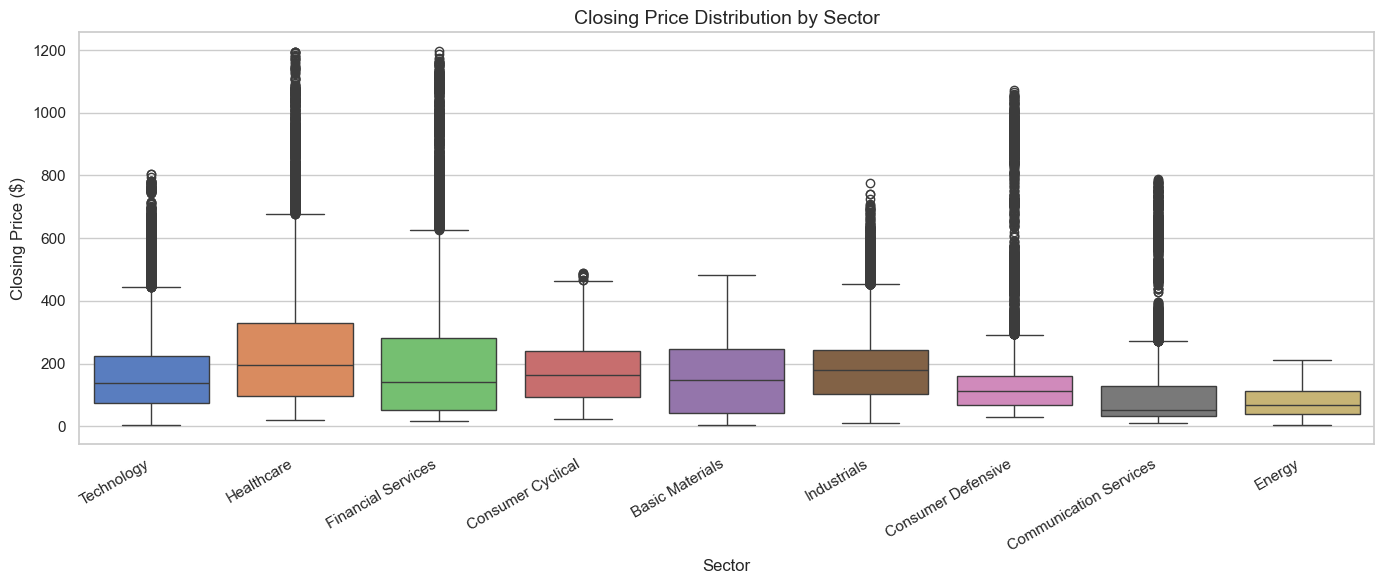

In [7]:
# Distribution of closing prices by sector
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Sector', y='Close', palette='muted')
plt.title('Closing Price Distribution by Sector', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Closing Price ($)')
plt.tight_layout()
plt.show()

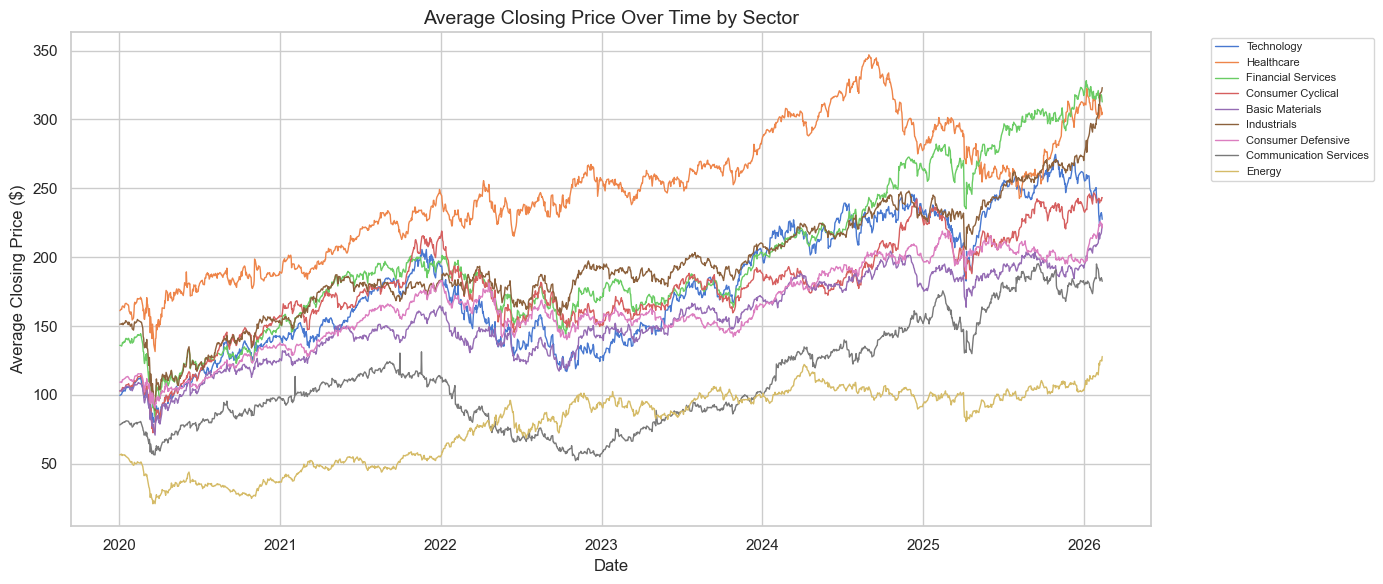

In [8]:
# Average closing price over time by sector
sector_time = df.groupby(['Date', 'Sector'])['Close'].mean().reset_index()

plt.figure(figsize=(14, 6))
for sector in df['Sector'].unique():
    subset = sector_time[sector_time['Sector'] == sector]
    plt.plot(subset['Date'], subset['Close'], label=sector, linewidth=1)

plt.title('Average Closing Price Over Time by Sector', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Closing Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

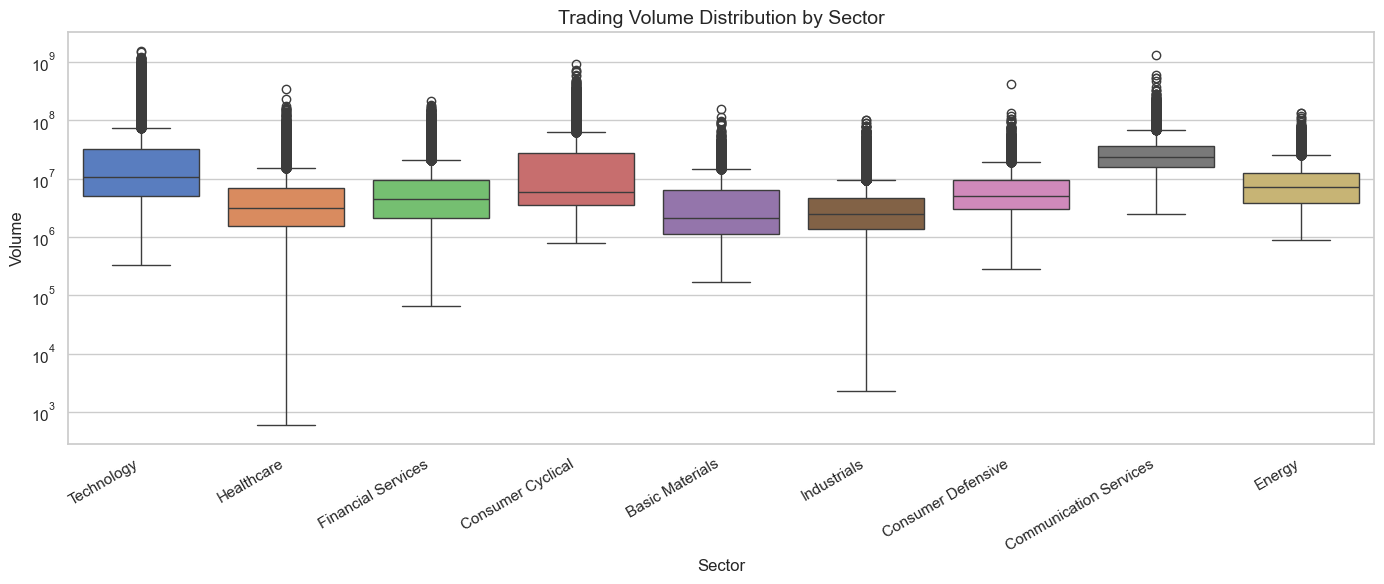

In [9]:
# Volume distribution by sector
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Sector', y='Volume', palette='muted')
plt.title('Trading Volume Distribution by Sector', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Volume')
plt.yscale('log')
plt.tight_layout()
plt.show()

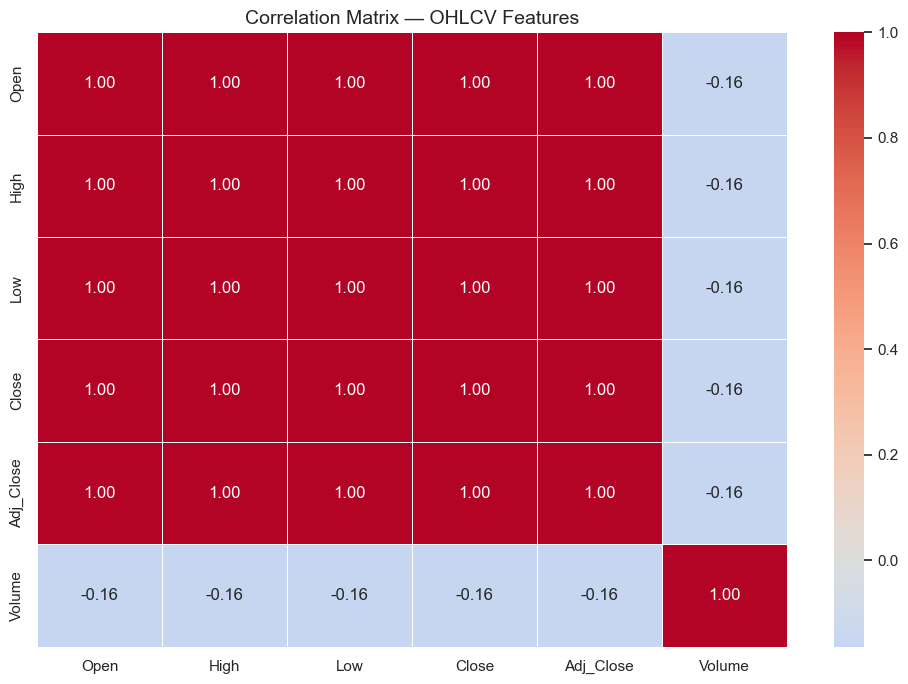

In [10]:
# Correlation heatmap of OHLCV features
plt.figure(figsize=(10, 7))
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Matrix — OHLCV Features', fontsize=14)
plt.tight_layout()
plt.show()

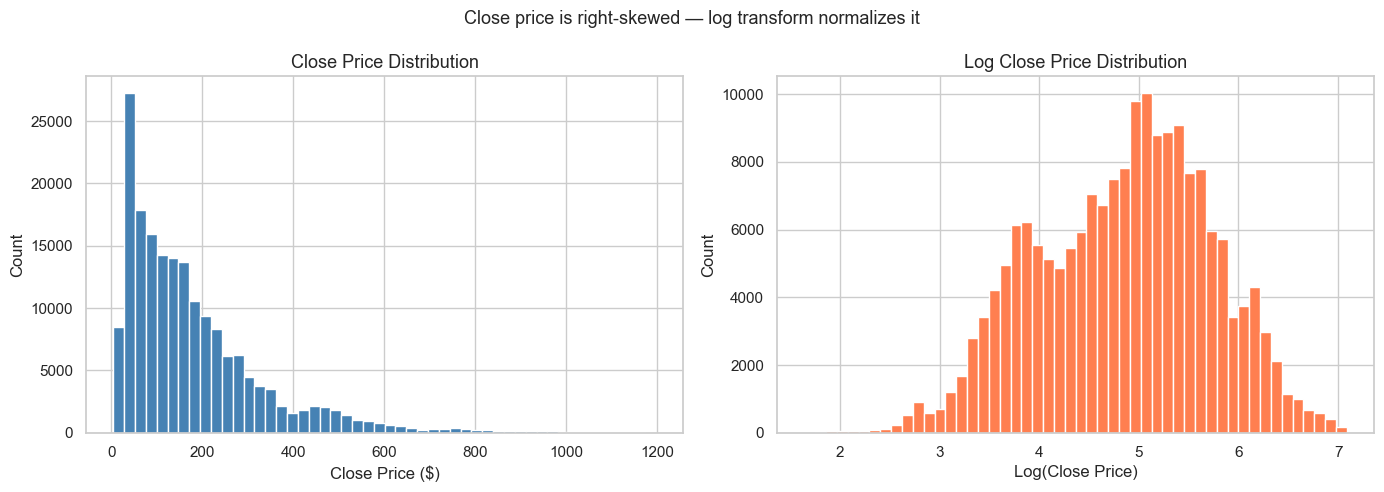

In [11]:
# Closing price distribution — check for skewness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Close'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Close Price Distribution', fontsize=13)
axes[0].set_xlabel('Close Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Close']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log Close Price Distribution', fontsize=13)
axes[1].set_xlabel('Log(Close Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Close price is right-skewed — log transform normalizes it', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Outlier Analysis

In [12]:
# IQR-based outlier detection on Close price
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]
print(f'Close price outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}% of data)')
print(f'IQR bounds: ${lower:.2f} — ${upper:.2f}')
print()
print('Top 10 outlier tickers:')
print(outliers['Ticker'].value_counts().head(10))

Close price outliers: 9,259 (5.0% of data)
IQR bounds: $-195.53 — $497.48

Top 10 outlier tickers:
Ticker
BLK     1382
REGN    1375
TMO      988
COST     807
INTU     748
LLY      631
ADBE     510
META     413
MA       329
GS       327
Name: count, dtype: int64


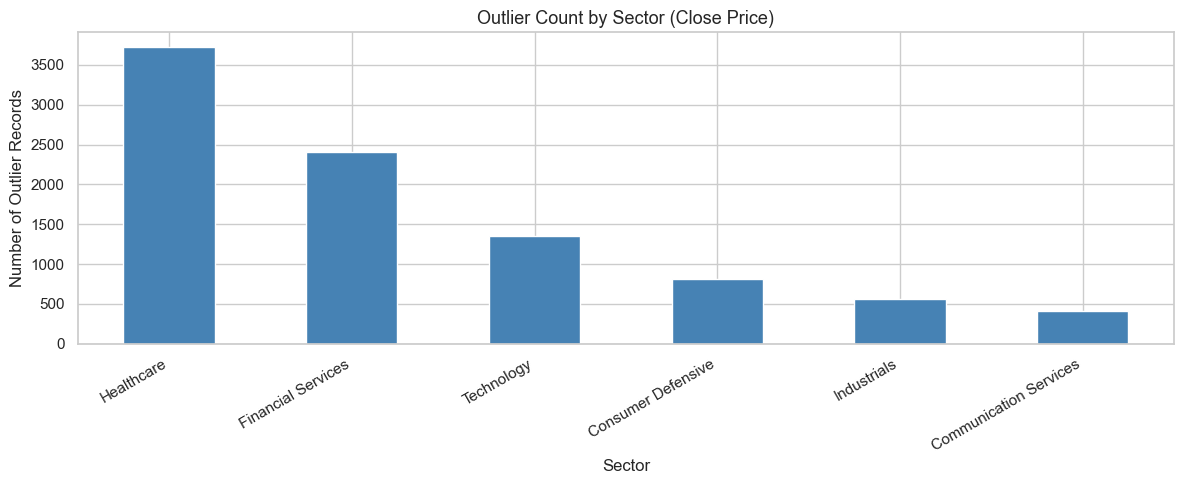

In [13]:
# Outliers by sector
outlier_sector = outliers.groupby('Sector').size().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
outlier_sector.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Outlier Count by Sector (Close Price)', fontsize=13)
plt.ylabel('Number of Outlier Records')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [14]:
# Engineer features from raw OHLCV data
df_feat = df.copy()

# Daily return %
df_feat['Daily_Return'] = df_feat.groupby('Ticker')['Close'].pct_change() * 100

# Price range (High - Low) as volatility proxy
df_feat['Price_Range'] = df_feat['High'] - df_feat['Low']

# 5-day and 20-day moving averages
df_feat['MA5']  = df_feat.groupby('Ticker')['Close'].transform(lambda x: x.rolling(5).mean())
df_feat['MA20'] = df_feat.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).mean())

# MA crossover signal (MA5 above MA20 = bullish)
df_feat['MA_Signal'] = (df_feat['MA5'] > df_feat['MA20']).astype(int)

# Next day close (target variable)
df_feat['Next_Close'] = df_feat.groupby('Ticker')['Close'].shift(-1)

# Log volume
df_feat['Log_Volume'] = np.log1p(df_feat['Volume'])

# Drop rows with NaN from rolling windows and target
df_feat = df_feat.dropna(subset=['Daily_Return', 'MA5', 'MA20', 'Next_Close'])

print('Feature engineered dataset shape:', df_feat.shape)
print('\nNew features:')
print(df_feat[['Daily_Return', 'Price_Range', 'MA5', 'MA20', 'MA_Signal', 'Log_Volume', 'Next_Close']].describe())

Feature engineered dataset shape: (181738, 18)

New features:
        Daily_Return    Price_Range            MA5           MA20  \
count  181738.000000  181738.000000  181738.000000  181738.000000   
mean        0.073932       4.089606     180.531178     179.861107   
std         2.201257       4.503721     158.593496     157.825305   
min       -44.994243       0.000000       4.679707       5.895269   
25%        -0.900903       1.349196      64.658143      64.242903   
50%         0.067396       2.732331     138.893906     138.667879   
75%         1.049586       5.115056     238.285970     237.390502   
max        43.973933     182.549988    1190.835498    1168.840472   

           MA_Signal     Log_Volume     Next_Close  
count  181738.000000  181738.000000  181738.000000  
mean        0.562596      15.506056     180.808065  
std         0.496068       1.246157     158.890268  
min         0.000000       6.398595       4.174429  
25%         0.000000      14.603343      64.818485 

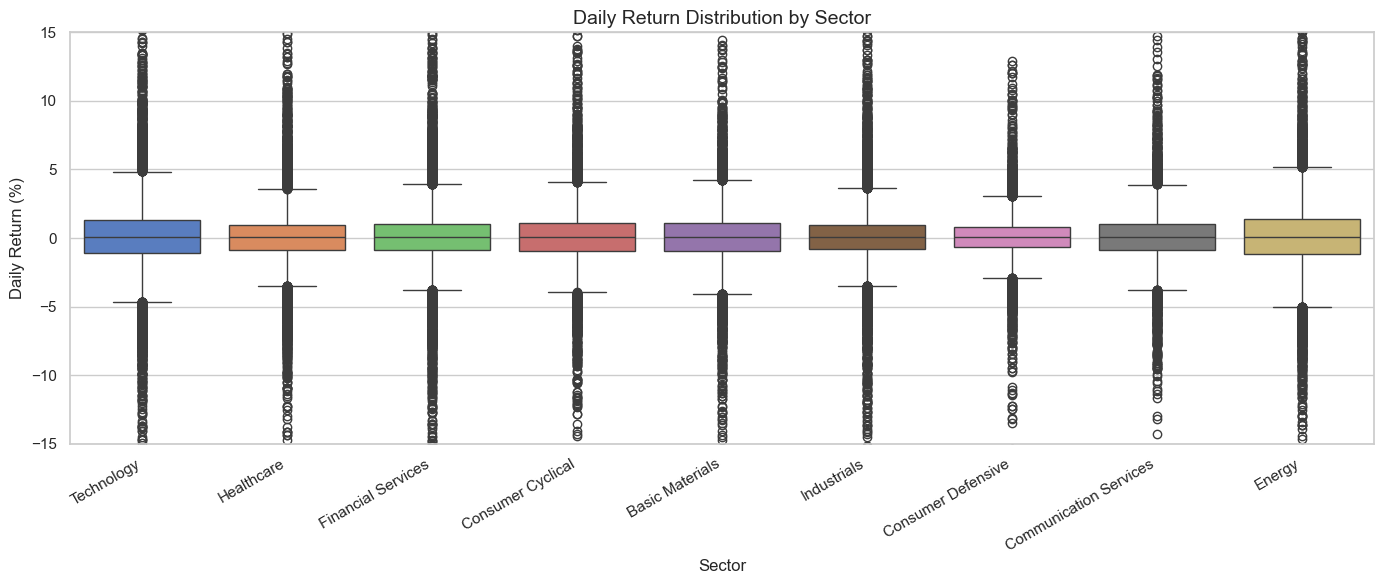

In [15]:
# Daily return distribution by sector
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_feat, x='Sector', y='Daily_Return', palette='muted')
plt.title('Daily Return Distribution by Sector', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Daily Return (%)')
plt.ylim(-15, 15)
plt.tight_layout()
plt.show()

In [16]:
# Average daily return and volatility by sector
sector_stats = df_feat.groupby('Sector').agg(
    Avg_Daily_Return=('Daily_Return', 'mean'),
    Volatility=('Daily_Return', 'std'),
    Avg_Volume=('Volume', 'mean')
).round(4).sort_values('Volatility', ascending=False)

print('=== Sector Statistics ===')
sector_stats

=== Sector Statistics ===


,Avg_Daily_Return,Volatility,Avg_Volume
Sector,,,
Energy,0.0937,2.8494,9.745678e+06
Technology,0.0991,2.5521,4.595441e+07
Consumer Cyclical,0.0791,2.3675,2.711736e+07
Basic Materials,0.0821,2.2415,5.063639e+06
Financial Services,0.0729,2.1319,8.856220e+06
Communication Services,0.0582,2.1267,3.086526e+07
Industrials,0.0750,1.9806,4.135821e+06
Healthcare,0.0543,1.9232,6.176982e+06
Consumer Defensive,0.0494,1.6981,7.830341e+06


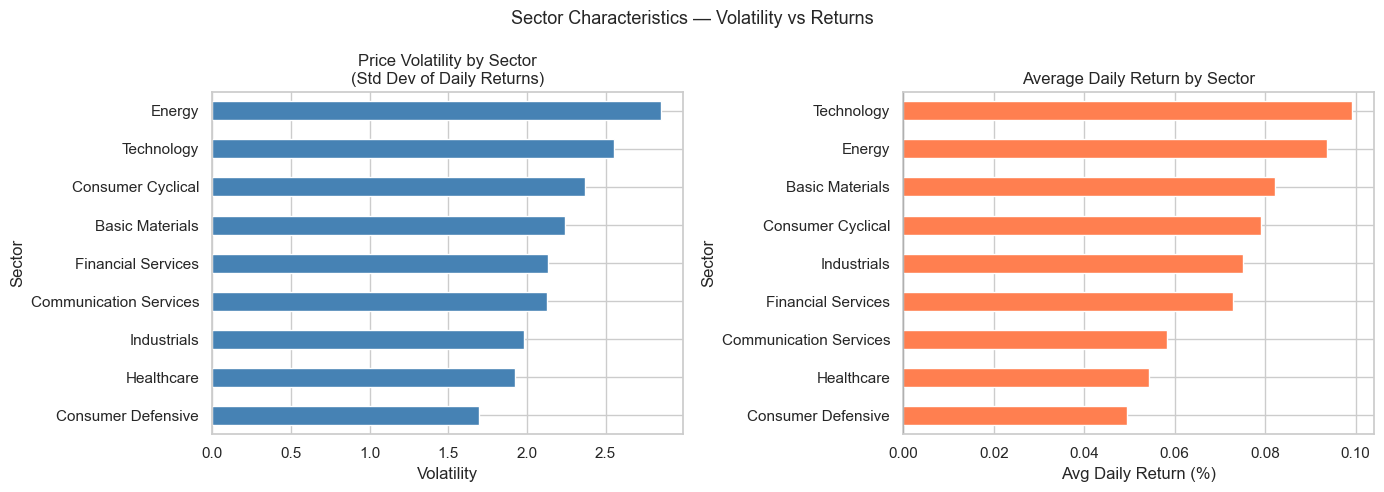

In [17]:
# Volatility by sector chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_stats['Volatility'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Price Volatility by Sector\n(Std Dev of Daily Returns)', fontsize=12)
axes[0].set_xlabel('Volatility')

sector_stats['Avg_Daily_Return'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Average Daily Return by Sector', fontsize=12)
axes[1].set_xlabel('Avg Daily Return (%)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Sector Characteristics — Volatility vs Returns', fontsize=13)
plt.tight_layout()
plt.show()

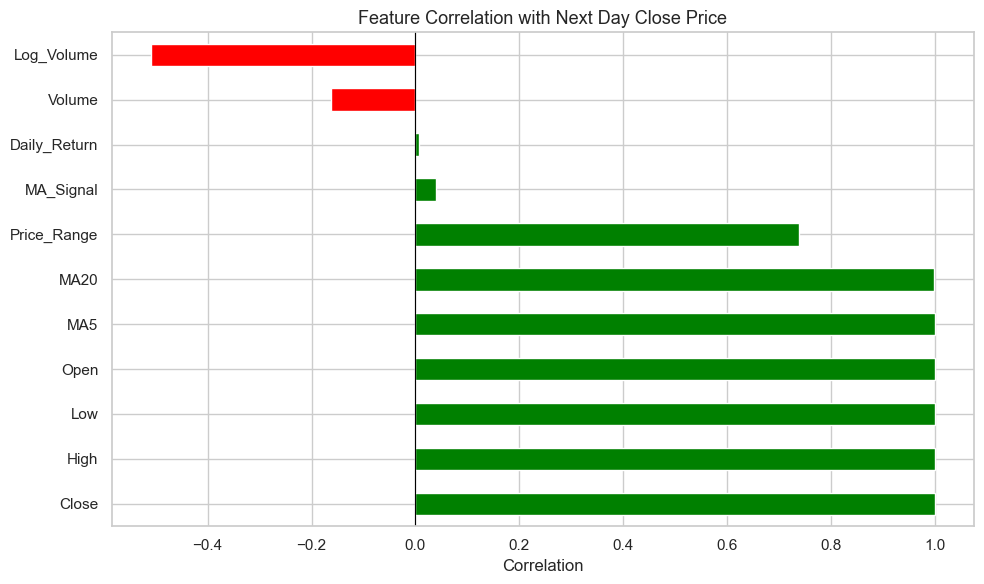

In [18]:
# Correlation of engineered features with Next_Close
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Daily_Return', 'Price_Range', 'MA5', 'MA20',
                'MA_Signal', 'Log_Volume']

corr_with_target = df_feat[feature_cols + ['Next_Close']].corr()['Next_Close'].drop('Next_Close').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Next Day Close Price', fontsize=13)
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 6. Baseline Model — Multiple Linear Regression

In [19]:
# Features and target
features = ['Open', 'High', 'Low', 'Close', 'Log_Volume',
            'Daily_Return', 'Price_Range', 'MA5', 'MA20', 'MA_Signal']
target = 'Next_Close'

X = df_feat[features]
y = df_feat[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (145390, 10)
Test set:     (36348, 10)


In [20]:
# Train baseline linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Baseline Model: Multiple Linear Regression ===')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')
print()
print('Evaluation metric rationale:')
print('RMSE measures average prediction error in the same units as the target (dollars).')
print('R² tells us how much of the variance in next-day close price is explained by our features.')
print('Both metrics together give a complete picture of model performance.')

=== Baseline Model: Multiple Linear Regression ===
RMSE: 4.4531
R²:   0.9992

Evaluation metric rationale:
RMSE measures average prediction error in the same units as the target (dollars).
R² tells us how much of the variance in next-day close price is explained by our features.
Both metrics together give a complete picture of model performance.


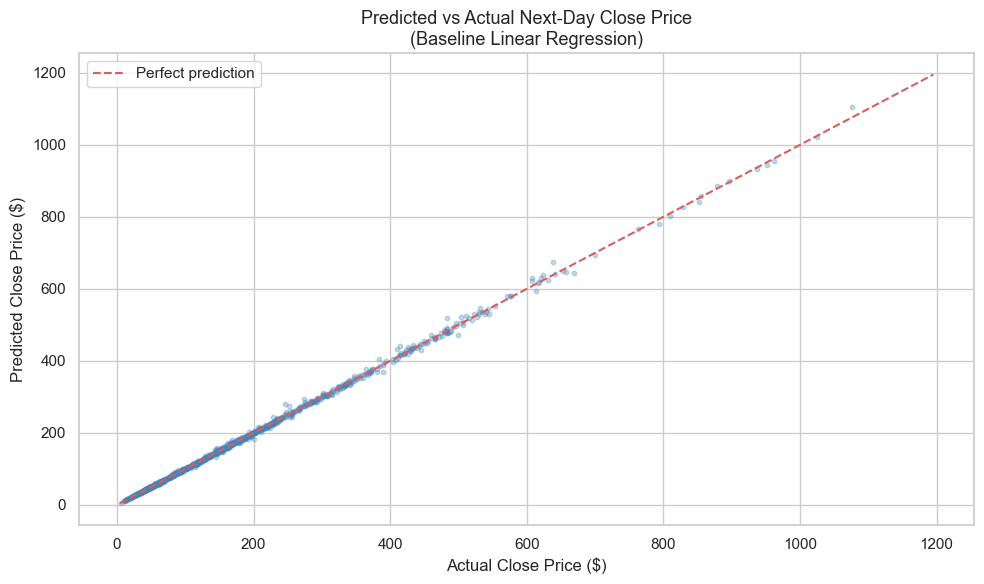

In [21]:
# Predicted vs actual plot
plt.figure(figsize=(10, 6))
sample = min(1000, len(y_test))
plt.scatter(y_test[:sample], y_pred[:sample], alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Predicted vs Actual Next-Day Close Price\n(Baseline Linear Regression)', fontsize=13)
plt.xlabel('Actual Close Price ($)')
plt.ylabel('Predicted Close Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Model performance by sector
df_test = X_test.copy()
df_test['Actual']    = y_test.values
df_test['Predicted'] = y_pred
df_test['Sector']    = df_feat.loc[X_test.index, 'Sector'].values

sector_perf = []
for sector in df_test['Sector'].unique():
    subset = df_test[df_test['Sector'] == sector]
    s_rmse = np.sqrt(mean_squared_error(subset['Actual'], subset['Predicted']))
    s_r2   = r2_score(subset['Actual'], subset['Predicted'])
    sector_perf.append({'Sector': sector, 'RMSE': round(s_rmse, 4), 'R2': round(s_r2, 4)})

sector_perf_df = pd.DataFrame(sector_perf).set_index('Sector').sort_values('RMSE')
print('=== Model Performance by Sector ===')
sector_perf_df

=== Model Performance by Sector ===


,RMSE,R2
Sector,,
Energy,1.7887,0.9984
Basic Materials,3.1026,0.9993
Communication Services,3.6608,0.9993
Consumer Defensive,3.8015,0.9995
Industrials,3.9560,0.9989
Consumer Cyclical,4.2472,0.9978
Financial Services,4.3812,0.9995
Technology,5.2030,0.9986
Healthcare,6.1490,0.9990


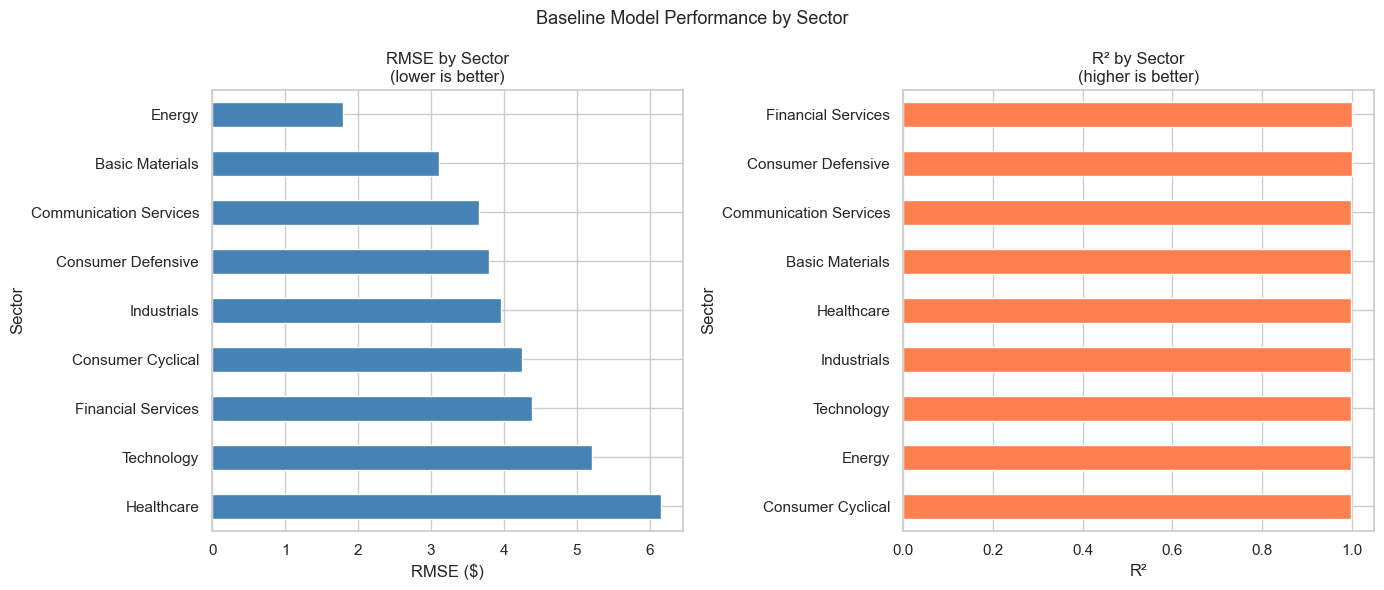

In [23]:
# RMSE by sector chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sector_perf_df['RMSE'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('RMSE by Sector\n(lower is better)', fontsize=12)
axes[0].set_xlabel('RMSE ($)')

sector_perf_df['R2'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('R² by Sector\n(higher is better)', fontsize=12)
axes[1].set_xlabel('R²')

plt.suptitle('Baseline Model Performance by Sector', fontsize=13)
plt.tight_layout()
plt.show()

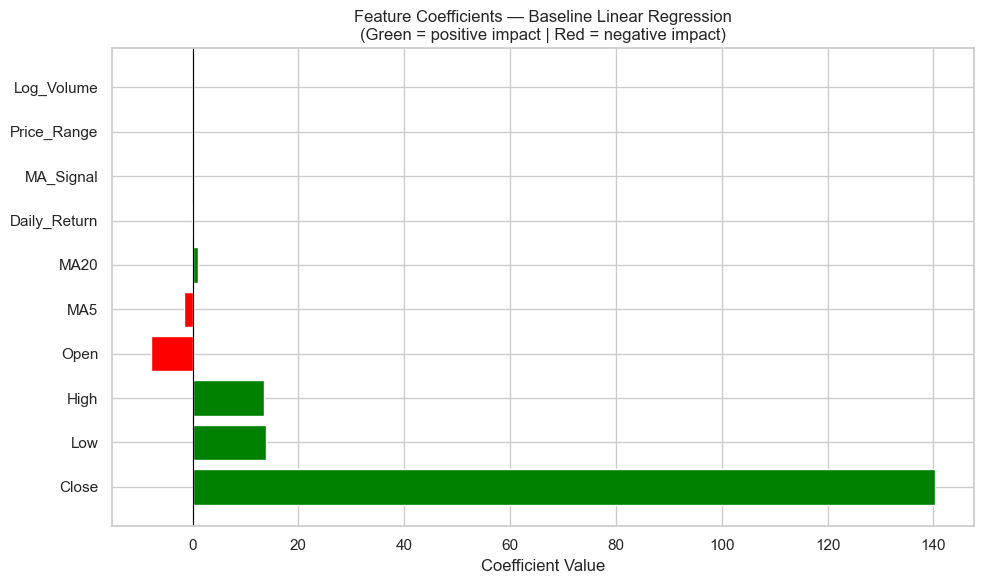

In [24]:
# Feature coefficients
coef_df = pd.DataFrame({
    'Feature':     features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Baseline Linear Regression\n(Green = positive impact | Red = negative impact)', fontsize=12)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()